# Clean transcripts

In [188]:
import pandas as pd
import pickle

file_name = "4350_vimeo_videos.parquet"
df = pd.read_parquet(file_name)
df = df.loc[~df["transcript_content"].isna()]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3344 entries, 2 to 4349
Data columns (total 45 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   uri                          3344 non-null   object
 1   name                         3344 non-null   object
 2   description                  0 non-null      object
 3   type                         3344 non-null   object
 4   link                         3344 non-null   object
 5   player_embed_url             3344 non-null   object
 6   duration                     3344 non-null   int64 
 7   width                        3344 non-null   int64 
 8   language                     3344 non-null   object
 9   height                       3344 non-null   int64 
 10  embed                        3344 non-null   object
 11  created_time                 3344 non-null   object
 12  modified_time                3344 non-null   object
 13  release_time                 3344 non-

In [189]:
import re

# Clean the transcript content
def clean_transcript(transcript):
    if not transcript:
        return None
    # Remove WEBVTT header and timestamps
    cleaned = re.sub(r'WEBVTT\n\n', '', transcript)  # Remove WEBVTT header
    cleaned = re.sub(r'\d+\n\d{2}:\d{2}:\d{2}\.\d{3} --> \d{2}:\d{2}:\d{2}\.\d{3}\n', '', cleaned)  # Remove timestamps
    cleaned = re.sub(r"\b[Uu][mh]\b[.,!?;]*", "", cleaned) # Remove fillers
    cleaned = re.sub(r'\n+', ' ', cleaned)  # Replace multiple newlines with a single space
    cleaned = re.sub(r"\s\s+", " ", cleaned) # Remove extra whitespaces
    cleaned = cleaned.strip()  # Remove leading/trailing spaces
    return cleaned

def remove_fillers(transcript):
    cleaned = re.sub(r"\b[Uu][mh]\b[.,!?;]*", "", transcript)
    return cleaned

# Apply the cleaning function to the DataFrame
df['cleaned_transcript'] = df['transcript_content'].apply(clean_transcript)
# df["cleaned2"] = df["cleaned_transcript"].map(clean_transcript)

In [51]:
print("Left")
print(re.sub(r"\b[Uu][mh]\b[.,!?;]*", "", "Um... hello"))
print(re.sub(r"\b[Uu][mh]\b[.,!?;]*", "", "Um, hello"))
print(re.sub(r"\b[Uu][mh]\b[.,!?;]*", "", "Um hello"))
print(re.sub(r"\b[Uu][mh]\b[.,!?;]*", "", ". Uh, hello"))
print(re.sub(r"\b[Uu][mh]\b[.,!?;]*", "", ".Uh hello"))

Left
 hello
 hello
 hello
.  hello
. hello


In [190]:
df["transcript_len"] = df["cleaned_transcript"].map(lambda x: len(x))

In [191]:
df.to_parquet("cleaned_transcripts.parquet")

In [57]:
fname = "884863197_dsbc-b14-w4-webscraping-presentations_Original.vtt"

with open("transcript.txt", "w") as f:
    f.write(df_orig.loc[df["vtt_filename"] == fname]["cleaned_transcript"].iloc[0])

In [58]:
df.sort_values(by="transcript_len", ascending=False, inplace=True)

In [59]:
pd.set_option('display.max_colwidth', None)
df[["vtt_filename", "transcript_len"]].head(20)

,vtt_filename,transcript_len
3263,918743175_Generative_AI__NoCode_Course_b1_2024-03-02_145656.vtt,285410
3250,919401692_generative_ai__nocode_course_day_1_part_1.vtt,285410
3232,920058805_generative_ai__nocode_course_day_1_part_2.vtt,285410
3162,921605438_Generative_AI__NoCode_Course_b1_2024-03-09_150108.vtt,248160
2905,923495030_Day_2_Intermediate_Excel.vtt,167438
3284,918216143_Applied_Business_Intelligence_Program_2024-03-01_002402.vtt,167438
4348,884863197_dsbc-b14-w4-webscraping-presentations_Original.vtt,165553
2776,926749182_MLOps_CICD_Intro_Github_Action_Steven.vtt,153762
28,1027544703_B7_-_MLAI_Engineering_Lectures__Lab_2024-11-08_000016.vtt,153186
3172,920852916_B7_-_Evening_Lectures__Lab_SQL_2024-03-08_003210.vtt,151701


In [60]:
df["tags"] = ""

In [61]:
df[["vtt_filename", "transcript_len", "tags"]].to_csv("transcript_filenames_and_lengths.csv", index=False)

In [62]:
df = pd.read_csv("transcript_filenames_and_lengths.csv")
df.head()

,vtt_filename,transcript_len,tags
0,918743175_Generative_AI__NoCode_Course_b1_2024-03-02_145656.vtt,285410,NaN
1,919401692_generative_ai__nocode_course_day_1_part_1.vtt,285410,NaN
2,920058805_generative_ai__nocode_course_day_1_part_2.vtt,285410,NaN
3,921605438_Generative_AI__NoCode_Course_b1_2024-03-09_150108.vtt,248160,NaN
4,923495030_Day_2_Intermediate_Excel.vtt,167438,NaN


# Tag transcripts by file name

In [63]:
from openai import OpenAI
from dotenv import load_dotenv
import os

load_dotenv(override=True)

True

In [ ]:
idx_start = 1000
n = len(df)


# system_message = """
# You are a content tagging assistant.
# The user will give you the file name of a transcript.
# The transcripts are from lectures.
# You will identify the most likely tag based on the file name.
# You must choose a tag from this list: [machine learning engineering, data analysis, data engineering, data science].
# Return only the tag; do not return any other text.
# """

# system_message = """
# You are a content tagging assistant.
# The user will give you the file name of a transcript.
# The transcripts are from lectures.
# You will identify the most likely tag based on the file name.
# These are the tags: ["Machine Learning Engineering", "Data Analysis", "Data Engineering", "Data Science"].
# Here are some examples of topics for each tag:
# * "Machine Learning Engineering": AI, Large Language Model, Computer Vision, MLOps
# * "Data Science": Data Science
# * "Data Analysis": Data Analytics, Analytics
# * "Data Engineering": Data Engineer, Big Data Engineer, Cloud Engineer, DevOps Engineer
# If none of the tags apply, simply return an empty string.
# Return only the tag; do not return any other text.
# """

client = OpenAI()
def get_completion(prompt, model="gpt-4o-mini"):
    messages = [{"role": "user", "content": prompt}]
    response = client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=0,
        max_completion_tokens=20,
    )
    return response.choices[0].message.content

for idx in range(idx_start, idx_start+n):
    fname = df.iloc[idx]["vtt_filename"]
    print(f"{idx}: {fname}")

    # Additional examples to add
        # Data analysis: visualization, tableau

    prompt = f"""
    I am doing a content tagging project. The goal of the project is to tag teaching materials.

    Tags: [Machine Learning Engineering, Data Analysis, Data Engineering, Data Science, Other].

    Here are some examples of topics for each tag:
    * Machine Learning Engineering: AI, Generative AI, Large Language Model, Computer Vision, MLOps
    * Data Science: Data Science
    * Data Analysis: Data Analytics, Analytics, Excel, Business Intelligence, SQL
    * Data Engineering: Data Engineer, Big Data Engineer, Cloud Engineer, DevOps Engineer, Spark
    * Other: Web Scraping

    I will give you a file name, delimited in triple backticks, and you will identify the most likely tag based on the file name.
    
    Respond only with the tag, without quotes.

    If none of the tags apply, respond with an empty string, "".

    File name: ```{fname}```
    """

    completion = get_completion(prompt)

    df.loc[idx, "tags"] = completion
    print(completion)
    print("-"*50)

df.to_csv("transcript_filenames_and_lengths.csv")

100: 964010755_Data_Engineer_B11_Thursday_Lecture_2024-06-20_232636.vtt
Data Engineering
--------------------------------------------------
101: 915821250_Thursday_Lecture_MLE-B6__ML_Intro__Ali_Madani.vtt
Machine Learning Engineering
--------------------------------------------------
102: 943895520_B7_-_Evening_Lectures__Lab_ML_2024-05-07_232739.vtt
Machine Learning Engineering
--------------------------------------------------
103: 1015082573_Data_Engineer_B11_Tuesday_Lecture_2024-10-01_232825.vtt
Data Engineering
--------------------------------------------------
104: 904314010_Thursday_Lecture_MLE-B4_2024-01-18_Amazon_SageMaker.vtt
Machine Learning Engineering
--------------------------------------------------
105: 923947186_Data_Engineer_B10_Thursday_Lecture_2024-03-15_232823.vtt
Data Engineering
--------------------------------------------------
106: 918917400_Sunday_Lecture_MLE_-_B6___Unsupervised_Learning__Ali_Madani.vtt
Machine Learning Engineering
-----------------------------

# Run word cloud on file names for each tag

In [177]:
def clean_titles(title):
    # Remove WEBVTT header and timestamps
    cleaned = title.lower()
    cleaned = " ".join(re.split(r"[-_]", cleaned))
    cleaned = re.sub(r".vtt", "", cleaned)
    cleaned = re.sub(r"\d+", "", cleaned)
    cleaned = re.sub(r"\b\w{1}\b", "", cleaned)
    cleaned = re.sub(r"monday|tuesday|wednesday|thursday|friday|saturday|sunday|evening|morning|daily|\bday\b", "", cleaned)
    cleaned = re.sub(r"\blabs?\b|\blectures?\b|\bbootcamps?\b|\bta oh\b", "", cleaned)
    cleaned = re.sub(r"\bfundamentals?\b", "", cleaned)
    cleaned = re.sub(r"\bintro\b|\bintroduction\b|\bintroductory\b", "", cleaned)
    cleaned = re.sub(r"\bindrani\b", "", cleaned)
    cleaned = re.sub(r"\bprograms?\b", "", cleaned)
    cleaned = re.sub(r"\bweclouddata\b|\bwecloud\b", "", cleaned)
    cleaned = re.sub(r"\bintermediate\b", "", cleaned)
    cleaned = re.sub(r"\s\s+", " ", cleaned) # Remove extra whitespaces
    cleaned = cleaned.strip()  # Remove leading/trailing spaces
    return cleaned

In [178]:
df["clean_title"] = df["vtt_filename"].map(clean_titles)

In [179]:
df.head()

,Unnamed: 0,vtt_filename,transcript_len,tags,clean_title
0,0,918743175_Generative_AI__NoCode_Course_b1_2024-03-02_145656.vtt,285410,Machine Learning Engineering,generative ai nocode course
1,1,919401692_generative_ai__nocode_course_day_1_part_1.vtt,285410,Machine Learning Engineering,generative ai nocode course part
2,2,920058805_generative_ai__nocode_course_day_1_part_2.vtt,285410,Machine Learning Engineering,generative ai nocode course part
3,3,921605438_Generative_AI__NoCode_Course_b1_2024-03-09_150108.vtt,248160,Machine Learning Engineering,generative ai nocode course
4,4,923495030_Day_2_Intermediate_Excel.vtt,167438,Data Analysis,excel


In [181]:
df.to_csv("transcript_filenames_and_lengths.csv")

In [ ]:
# df = pd.read_csv("transcript_filenames_and_lengths.csv")

# df["tags"].value_counts()

tags
Machine Learning Engineering    422
Data Engineering                235
Data Science                    156
Data Analysis                   102
""                               81
Other                             4
Name: count, dtype: int64

Machine Learning Engineering


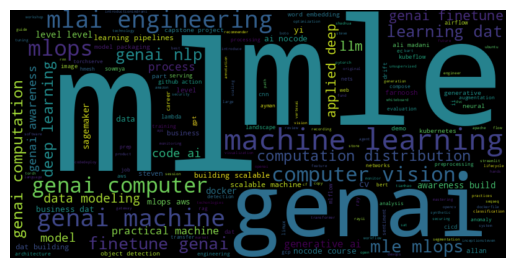

Data Engineering


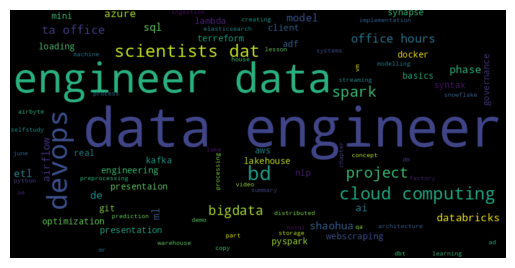

Data Science


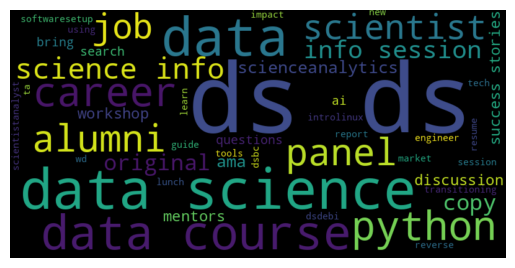

Data Analysis


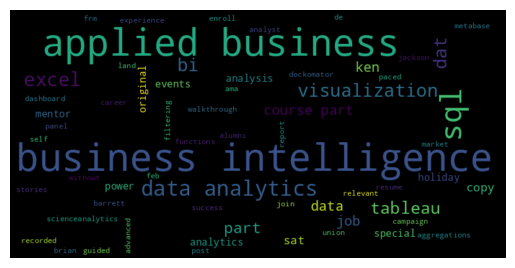

""


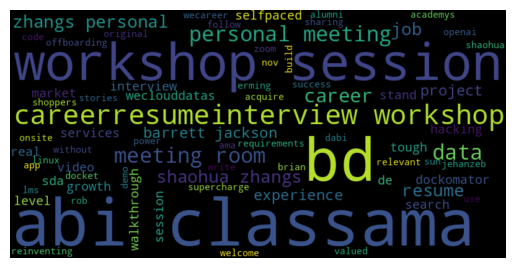

Other


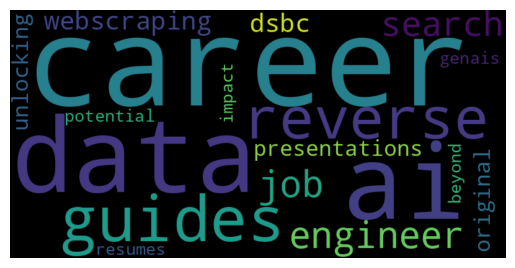

In [180]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

for tag in df["tags"].value_counts().index:
    df_slice = df.loc[df["tags"] == tag]
    text = " ".join(df_slice["clean_title"])
    wordcloud = WordCloud(width=800, height=400).generate(text)

    print(tag)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()
    # plt.title(tag)
    

# Recursive chunking

In [192]:
df = pd.read_csv("transcript_filenames_and_lengths.csv")
df_transcripts = pd.read_parquet("cleaned_transcripts.parquet")

In [219]:
df.head(20)

,Unnamed: 0.1,Unnamed: 0,vtt_filename,transcript_len,tags,clean_title
0,0,0,918743175_Generative_AI__NoCode_Course_b1_2024-03-02_145656.vtt,285410,Machine Learning Engineering,generative ai nocode course
1,1,1,919401692_generative_ai__nocode_course_day_1_part_1.vtt,285410,Machine Learning Engineering,generative ai nocode course part
2,2,2,920058805_generative_ai__nocode_course_day_1_part_2.vtt,285410,Machine Learning Engineering,generative ai nocode course part
3,3,3,921605438_Generative_AI__NoCode_Course_b1_2024-03-09_150108.vtt,248160,Machine Learning Engineering,generative ai nocode course
4,4,4,923495030_Day_2_Intermediate_Excel.vtt,167438,Data Analysis,excel
5,5,5,918216143_Applied_Business_Intelligence_Program_2024-03-01_002402.vtt,167438,Data Analysis,applied business intelligence
6,6,6,884863197_dsbc-b14-w4-webscraping-presentations_Original.vtt,165553,Other,dsbc webscraping presentations original
7,7,7,926749182_MLOps_CICD_Intro_Github_Action_Steven.vtt,153762,Machine Learning Engineering,mlops cicd github action steven
8,8,8,1027544703_B7_-_MLAI_Engineering_Lectures__Lab_2024-11-08_000016.vtt,153186,Machine Learning Engineering,mlai engineering
9,9,9,920852916_B7_-_Evening_Lectures__Lab_SQL_2024-03-08_003210.vtt,151701,Data Analysis,sql


In [220]:
idx = 8
content = df_transcripts.loc[df_transcripts["vtt_filename"] == df.loc[idx, "vtt_filename"]].iloc[0]["cleaned_transcript"]
print(content)

Hello everyone. let's wait couple of minutes. but before that, can you let me know, if somebody has downloaded a virtual box in tu because I want to kind of, go through step by step, you know, with the whole process of installation with you. Yeah, I, I installed it, I installed a BUN two in, in my virtual machine, and I was trying to, lemme think, I think, I think I also installed the SSH server open. SSH server. Yeah. Yeah. On your, on your computer, right? On My computer, yeah. And I also installed Visual Studio Code. Perfect. Okay. So, can you share your screen, because I want to go through the whole process with you because I already have installed, so if you have the virtual box, anyone can follow along and they can also like install the whole thing so I can, I can show you step by step what you need to do in order to set it up. Sure. Okay. So you already have installed Ubuntu as well? Yeah. Okay. okay. So is there anyone else who has not installed Ubuntu yet? I have not installed

In [ ]:
from haystack import Document, Pipeline
from haystack.components.preprocessors import DocumentCleaner, DocumentSplitter, RecursiveDocumentSplitter

sample_doc = Document(id="dummy", embedding=[0.1, 0.1], content=content)

splitting_options = {
    "split_length": 100,
    "split_overlap": 20,
    "split_unit": "word",
}

splitting_options = {
    "split_length": 300,
    "split_overlap": 60,
    "split_unit": "word",
}

pipe = Pipeline()
pipe.add_component("cleaner", DocumentCleaner())
pipe.add_component("splitter", RecursiveDocumentSplitter(**splitting_options))
pipe.connect("cleaner", "splitter")

🚅 Components
  - cleaner: DocumentCleaner
  - splitter: RecursiveDocumentSplitter
🛤️ Connections
  - cleaner.documents -> splitter.documents (List[Document])

In [222]:
docs = pipe.run({"cleaner": {"documents": [sample_doc]}})
docs = docs["splitter"]["documents"]
print(len(docs))
lengths = [len(doc.content) for doc in docs]
print(min(lengths))
print(max(lengths))

No abbreviations file found for en. Using default abbreviations.


367
453
619


In [223]:
import os

fname = "split_transcript.txt"
if os.path.exists(fname):
    os.remove(fname)

for doc in docs:
    with open(fname, "a") as f:
        f.write(f"{doc.content}\n{"-"*50}\n")

In [19]:
import random
import os

In [18]:
random.randint(0, len(df)-1)

359

In [55]:
for _ in range(10):
    idx = random.randint(0, len(df)-1)
    fname = f"transcript{idx}_v2.txt"

    if os.path.exists(fname):
        os.remove(fname)
    
    with open(fname, "a") as f:
        for col in ["name", "vtt_filename", "transcript_content", "cleaned_transcript"]:
            # print(f"{col}: {df.iloc[idx][col]}")
            # print("-"*100)
            f.write(f"{col}:\n")
            f.write(df.iloc[idx][col])
            f.write("\n")
            f.write("-"*100)
            f.write("\n")

In [25]:
df[["vtt_filename", "transcript_len"]].to_csv("transcript_names_lens.csv")

In [18]:
df = df.loc[~df["transcript_content"].isnull()]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3344 entries, 2 to 4349
Data columns (total 45 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   uri                          3344 non-null   object
 1   name                         3344 non-null   object
 2   description                  0 non-null      object
 3   type                         3344 non-null   object
 4   link                         3344 non-null   object
 5   player_embed_url             3344 non-null   object
 6   duration                     3344 non-null   int64 
 7   width                        3344 non-null   int64 
 8   language                     3344 non-null   object
 9   height                       3344 non-null   int64 
 10  embed                        3344 non-null   object
 11  created_time                 3344 non-null   object
 12  modified_time                3344 non-null   object
 13  release_time                 3344 non-

In [28]:
types = df["transcript_content"].map(lambda x: type(x))
types.value_counts()

transcript_content
<class 'str'>    3344
Name: count, dtype: int64

In [29]:
lengths = df["transcript_content"].map(lambda x: len(x))
lengths.describe()

count      3344.000000
mean      81002.195873
std       78788.119732
min          23.000000
25%       15187.750000
50%       50537.500000
75%      138289.750000
max      554683.000000
Name: transcript_content, dtype: float64

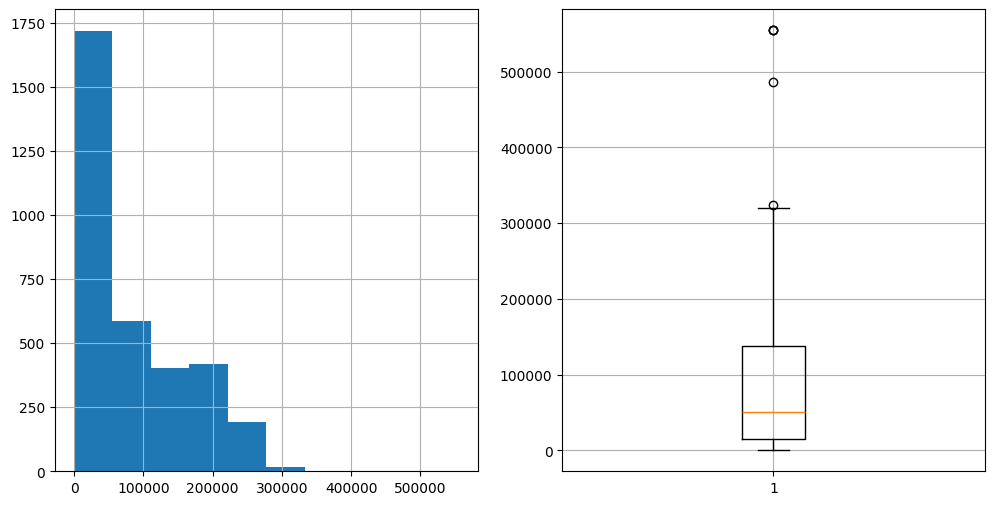

In [45]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12,6))
# axs.boxplot(lengths)
axs[0].hist(lengths)
axs[0].grid()
axs[1].boxplot(lengths)
axs[1].grid()

In [60]:
cond = lengths < 30
cond = (lengths >=30) & (lengths < 100)
cond = (lengths >= 100) & (lengths < 200)
cond = (lengths >= 200) & (lengths < 300)
cond = (lengths >= 300) & (lengths < 1000)
cond = (lengths >= 1000) & (lengths < 2000)
print(f"Number of rows: {sum(cond)}")
print("-"*20)
for _, row in df.loc[cond].iterrows():
    print(row["transcript_content"])
    print('-'*20)
# .iloc[0]["transcript_content"]

Number of rows: 115
--------------------
WEBVTT

1
00:00:03.035 --> 00:00:03.895
Hi everyone.

2
00:00:03.895 --> 00:00:05.295
Thank you for joining tonight

3
00:00:05.475 --> 00:00:07.735
and, uh, we're excited to have this event.

4
00:00:07.955 --> 00:00:11.175
And I'm Adam, I'm the program manager from W Cloud Data.

5
00:00:11.955 --> 00:00:15.215
Uh, so today's topics is enterprise AI

6
00:00:15.555 --> 00:00:18.935
and uh, is the mainly focused on the data operations

7
00:00:18.935 --> 00:00:21.375
and the machine learning operations strategies.

8
00:00:22.195 --> 00:00:26.895
Uh, we will, we invite Lisa and is our special guest,

9
00:00:27.075 --> 00:00:28.975
and she, she will be the speaker tonight.

10
00:00:29.555 --> 00:00:32.775
She is the engineer and then now product manager.

11
00:00:33.275 --> 00:00:37.665
And from, uh, data, uh, Strat to,

12
00:00:38.325 --> 00:00:41.305
uh, from the, she now is a,

13
00:00:43.315 --> 00:00:48.085
Lisa is a data engineer and 